<a href="https://colab.research.google.com/github/Abhishek213-013/Gesture_V2_CNN_LSTM_Time/blob/main/Gesture_V2_CNN_LSTM_Time.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow pandas numpy matplotlib seaborn scikit-learn joblib

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [3]:
import zipfile

zip_path = "/content/data_v2.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


**Check Dataset Folders**

In [4]:
base_path = "/content/dataset/data"

print(os.listdir(base_path))

['left', 'right', 'up', 'down', 'idle']


**Load Dataset (WITH TIME COLUMN)**

In [5]:
X = []
y = []
label_map = {}

window_size = 50
label_index = 0

for gesture_name in os.listdir(base_path):

    gesture_folder = os.path.join(base_path, gesture_name)

    if not os.path.isdir(gesture_folder):
        continue

    label_map[label_index] = gesture_name

    print(f"Loading Gesture: {gesture_name}")

    for file in os.listdir(gesture_folder):

        if file.endswith('.csv'):

            file_path = os.path.join(gesture_folder, file)

            df = pd.read_csv(file_path)

            # Keep numeric columns including time
            df = df.select_dtypes(include=[np.number])

            data = df.values

            # Fixed window size
            if len(data) >= window_size:

                data = data[:window_size]

                X.append(data)
                y.append(label_index)

    label_index += 1

X = np.array(X)
y = np.array(y)

print()
print("Dataset Loaded Successfully")
print("Dataset Shape:", X.shape)
print("Labels Shape:", y.shape)
print()
print("Label Map:")
print(label_map)

Loading Gesture: left
Loading Gesture: right
Loading Gesture: up
Loading Gesture: down
Loading Gesture: idle

Dataset Loaded Successfully
Dataset Shape: (124, 50, 13)
Labels Shape: (124,)

Label Map:
{0: 'left', 1: 'right', 2: 'up', 3: 'down', 4: 'idle'}


**Normalize Dataset**

In [6]:
from sklearn.preprocessing import StandardScaler

samples, timesteps, features = X.shape

X_reshaped = X.reshape(-1, features)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_reshaped)

X = X_scaled.reshape(samples, timesteps, features)

print("Normalization Complete")

Normalization Complete


**Split Train/Test Data**

In [7]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

num_classes = len(label_map)

y_cat = to_categorical(y, num_classes)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_cat,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (99, 50, 13)
Testing Shape: (25, 50, 13)


**Build CNN + LSTM Model**

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization

model = Sequential()

# Input Layer
model.add(Input(shape=(50, 13)))

# CNN Layer
model.add(Conv1D(
    filters=64,
    kernel_size=3,
    activation='relu'
))

model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.3))

# LSTM Layer
model.add(LSTM(64))
model.add(Dropout(0.3))

# Dense Layer
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

# Output Layer
model.add(Dense(num_classes, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 48, 64)         │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,325 (157.52 KB)

 Trainable params: 40,197 (157.02 KB)

 Non-trainable params: 128 (512.00 B)

**Add EarlyStopping**

In [9]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

**Train the Model**

In [10]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.2222 - loss: 1.6212 - val_accuracy: 0.4800 - val_loss: 1.4410
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5253 - loss: 1.2579 - val_accuracy: 0.6800 - val_loss: 1.2591
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7677 - loss: 0.9744 - val_accuracy: 0.9600 - val_loss: 1.0979
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8283 - loss: 0.8139 - val_accuracy: 0.9600 - val_loss: 0.9277
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9293 - loss: 0.6225 - val_accuracy: 0.9600 - val_loss: 0.7664
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9293 - loss: 0.4795 - val_accuracy: 0.9600 - val_loss: 0.6250
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9899 - loss: 0.3344 - val_accuracy: 0.9600 - val_loss: 0.4992
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9697 - loss: 0.2751 - val_accuracy: 0.9600 - val_loss: 0.3980


**Plot Accuracy Graph**

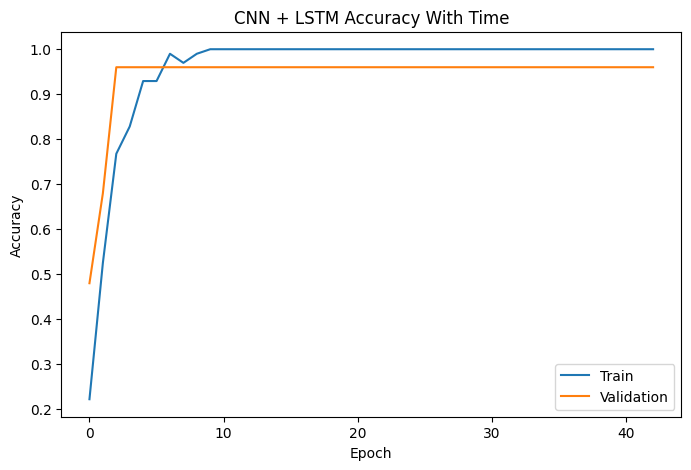

In [11]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('CNN + LSTM Accuracy With Time')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

**Plot Loss Graph**

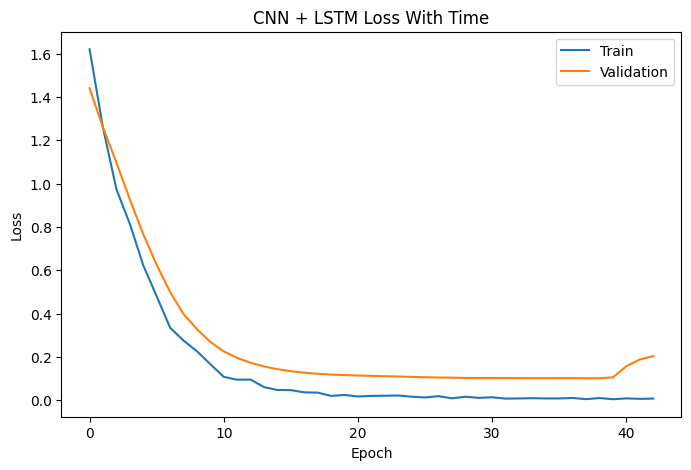

In [12]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('CNN + LSTM Loss With Time')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

**Evaluate Model**

In [13]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9600 - loss: 0.1008
Test Accuracy: 0.9599999785423279
Test Loss: 0.10077039897441864


**Generate Predictions**

In [14]:
predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 712ms/step


**Confusion Matrix**

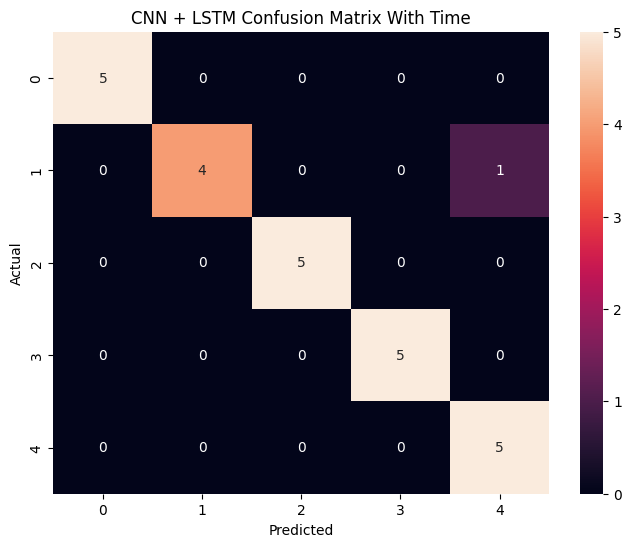

In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('CNN + LSTM Confusion Matrix With Time')

plt.show()

**Classification Report**

In [16]:
from sklearn.metrics import classification_report

print(classification_report(true_labels, predicted_labels))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      0.80      0.89         5
           2       1.00      1.00      1.00         5
           3       1.00      1.00      1.00         5
           4       0.83      1.00      0.91         5

    accuracy                           0.96        25
   macro avg       0.97      0.96      0.96        25
weighted avg       0.97      0.96      0.96        25



**Save the Model**

In [17]:
model.save("gesture_v2_cnn_lstm_with_time.h5")

print("Model Saved Successfully")

Model Saved Successfully


**Save the Scaler**

In [18]:
import joblib

joblib.dump(scaler, 'gesture_v2_scaler_with_time.save')

print("Scaler Saved Successfully")

Scaler Saved Successfully
